<a href="https://colab.research.google.com/github/Kaushgowda/flyrank-ml-internship/blob/main/work/notebooks/w05_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Kaushgowda/flyrank-ml-internship/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import ndcg_score

# Load dataset
df = pd.read_csv("content_refresh_anonymized (1).csv")

print("Dataset shape:", df.shape)
print("Target:", "engagement_rate")

Dataset shape: (9349, 44)
Target: engagement_rate


## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

In [6]:
import pandas as pd
import os # Import os module to check for file existence

# Features selected for the ranking task
features = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "scroll_events_90d",
    "content_age_days",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "scroll_rate",
    "ai_traffic_pct"
]

target = "engagement_rate"

# Load dataset (added to ensure df is defined)
csv_file_path = "content_refresh_anonymized (1).csv"
if not os.path.exists(csv_file_path):
    raise FileNotFoundError(f"File not found: {csv_file_path}. Please ensure the dataset is uploaded or available in the current directory.")
df = pd.read_csv(csv_file_path)

# Create modeling dataset
model_df = df[features + [target]].copy()

# Convert features to numeric
for col in features:
    model_df[col] = pd.to_numeric(
        model_df[col],
        errors="coerce"
    )

    model_df[col] = model_df[col].fillna(
        model_df[col].median()
    )

# Convert target
model_df[target] = pd.to_numeric(
    model_df[target],
    errors="coerce"
)

# Remove rows where target is missing
model_df = model_df.dropna(
    subset=[target]
)

X = model_df[features]
y = model_df[target]

print("Number of features:", len(features))
print("Training rows available:", len(model_df))
print("Target:", target)


Number of features: 15
Training rows available: 23365
Target: engagement_rate


## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

In [10]:
from sklearn.model_selection import train_test_split

# Reproducible train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print(
    "Test proportion:",
    round(len(X_test) / len(model_df), 3)
)


Training rows: 18692
Test rows: 4673
Test proportion: 0.2


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

In [12]:
from sklearn.ensemble import RandomForestRegressor

# Train Random Forest model

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train
)

# Generate predictions
y_pred = model.predict(X_test)

print("Model trained successfully.")
print(
    "Predictions generated:",
    len(y_pred)
)


Model trained successfully.
Predictions generated: 4673


In [13]:
import numpy as np

# Model ranking
model_order = np.argsort(-y_pred)

model_relevance = y_test.to_numpy()[model_order]

model_ndcg = ndcg_score(
    [y_test.to_numpy()],
    [y_pred]
)

print("Model NDCG:", round(model_ndcg, 4))
baseline_test = df.loc[X_test.index].copy()

# Calculate the same thresholds used in W04
search_median = df["search_volume"].median()
ctr_median = df["ctr"].median()
position_median = df["avg_position"].median()
age_median = df["content_age_days"].median()

baseline_test["baseline_score"] = 0

baseline_test.loc[
    baseline_test["search_volume"] >= search_median,
    "baseline_score"
] += 1

baseline_test.loc[
    baseline_test["ctr"] < ctr_median,
    "baseline_score"
] += 1

baseline_test.loc[
    baseline_test["avg_position"] > position_median,
    "baseline_score"
] += 1

baseline_test.loc[
    baseline_test["content_age_days"] >= age_median,
    "baseline_score"
] += 1

print(
    baseline_test[
        [
            "content_id",
            "baseline_score",
            "engagement_rate"
        ]
    ].head()
)
baseline_ndcg = ndcg_score(
    [baseline_test["engagement_rate"].to_numpy()],
    [baseline_test["baseline_score"].to_numpy()]
)

print("Baseline NDCG:", round(baseline_ndcg, 4))
comparison = pd.DataFrame({
    "Method": [
        "W04 Rule-Based Baseline",
        "Random Forest"
    ],
    "NDCG": [
        baseline_ndcg,
        model_ndcg
    ]
})

comparison

NameError: name 'np' is not defined

## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

In [ ]:
error_df = pd.DataFrame({
    "actual_engagement": y_test.values,
    "predicted_engagement": y_pred
})

error_df["absolute_error"] = (
    error_df["actual_engagement"]
    - error_df["predicted_engagement"]
).abs()

error_df = error_df.sort_values(
    "absolute_error",
    ascending=False
)

print("Largest prediction errors:")
display(error_df.head(10))

Largest prediction errors:


,actual_engagement,predicted_engagement,absolute_error
797,57.14,39.3427,17.7973
1281,50.00,64.5000,14.5000
97,66.67,56.0012,10.6688
1228,50.00,60.0000,10.0000
1678,50.00,60.0000,10.0000
1249,50.00,60.0000,10.0000
383,50.00,40.8086,9.1914
1548,18.29,9.8822,8.4078
524,25.00,17.9077,7.0923
330,50.00,56.0204,6.0204


,feature,importance
8,sessions_90d,0.414518
9,users_90d,0.317662
10,engaged_sessions_90d,0.250255
17,scroll_rate,0.010184
7,pageviews_90d,0.004205
13,content_age_days,0.000787
12,scroll_events_90d,0.000529
3,word_count,0.000415
15,ctr,0.000289
6,clicks_90d,0.000249


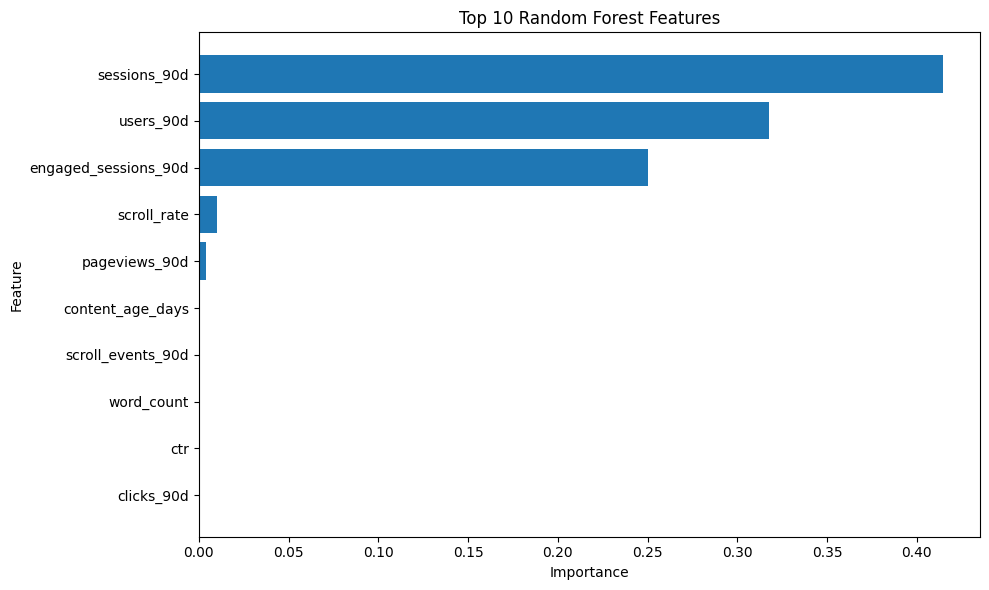

In [ ]:
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

display(feature_importance)
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Features")
plt.tight_layout()
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.